In [21]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape
from gtda.diagrams import PersistenceEntropy
from scipy.signal import find_peaks
from scipy.sparse.csgraph import shortest_path

In [22]:
class Segmentation_Persistent_Homology:
    
    def __init__(self, homology_type):
        '''
        Parameters:
        homology_type: 'ordinal_partition' or 'takens_embedding'
        point_summary_type: 'max_persistence', 'periodicity_score', 
                            'homology_classes_by_graph_order', 'norm_persistent_entropy'
        
        Returns:
        None
        '''
        self.homology_type = homology_type
        return
    
    def kernel_dist(self, persis1, persis2, sig = 1.0):
        kernel_func_12, kernel_func_11, kernel_func_22 = 0.0, 0.0, 0.0
        for pt1 in range(persis1.shape[1]):
            for pt2 in range(persis2.shape[1]):
                dist_1 = (persis1[0, pt1, 0]-persis2[0, pt2, 0])**2 + (persis1[0, pt1, 1]-persis2[0, pt2, 1])**2
                dist_2 = (persis1[0, pt1, 0]-persis2[0, pt2, 1])**2 + (persis1[0, pt1, 1]-persis2[0, pt2, 0])**2
                kernel_func_12 = kernel_func_12 + np.exp(-1.0/(8*sig)*dist_1) + np.exp(-1.0/(8*sig)*dist_2)        
        kernel_func_12 = 1.0/(8.0*np.pi*sig)*kernel_func_12
        
        for pt1 in range(persis1.shape[1]):
            for pt2 in range(persis1.shape[1]):
                dist_1 = (persis1[0, pt1, 0]-persis1[0, pt2, 0])**2 + (persis1[0, pt1, 1]-persis1[0, pt2, 1])**2
                dist_2 = (persis1[0, pt1, 0]-persis1[0, pt2, 1])**2 + (persis1[0, pt1, 1]-persis1[0, pt2, 0])**2
                kernel_func_11 = kernel_func_11 + np.exp(-1.0/(8*sig)*dist_1) + np.exp(-1.0/(8*sig)*dist_2)
        kernel_func_11 = 1.0/(8.0*np.pi*sig)*kernel_func_11
                
        for pt1 in range(persis2.shape[1]):
            for pt2 in range(persis2.shape[1]):
                dist_1 = (persis2[0, pt1, 0]-persis2[0, pt2, 0])**2 + (persis2[0, pt1, 1]-persis2[0, pt2, 1])**2
                dist_2 = (persis2[0, pt1, 0]-persis2[0, pt2, 1])**2 + (persis2[0, pt1, 1]-persis2[0, pt2, 0])**2
                kernel_func_22 = kernel_func_22 + np.exp(-1.0/(8*sig)*dist_1) + np.exp(-1.0/(8*sig)*dist_2)
        kernel_func_22 = 1.0/(8.0*np.pi*sig)*kernel_func_22
        
        dist_ker = (kernel_func_11 + kernel_func_22 -2*kernel_func_12)**0.5
        return dist_ker
        
        
    
    def get_persistence_diagram(self, ts_window):
        '''
        Parameters:
        ts_window: 1d numpy array (for ordinal_partition) ; 1d or 2d numpy array (for takens_embedding)
        
        Returns:
        None
        '''
        homology_dimensions = [1]
        
        if self.homology_type == 'ordinal_partition':           
            tau_curr, d_curr = 2, 5 # Hard-coded values (TO FIX later)
            indices = np.array([np.arange(i, i+d_curr*tau_curr, tau_curr) 
                                for i in range(ts_window.shape[0]-(d_curr-1)*tau_curr)])
            X_perm_window = ts_window[indices]
            X_tg = TransitionGraph().fit_transform([X_perm_window])[0]
            dist_matrix = shortest_path(X_tg)
            persis = VietorisRipsPersistence(metric = 'precomputed', homology_dimensions = homology_dimensions, 
                                                n_jobs = -1).fit_transform([dist_matrix])
            persis[np.isinf(persis)] = 1e2
            
        elif self.homology_type == 'takens_embedding':
            max_embedding_dimension, stride = 5, 1 # Hard-coded values (TO FIX later)
            max_time_delay = ts_window.shape[0]//(max_embedding_dimension + 1)

            TS_embedded = TakensEmbedding(parameters_type= 'search', time_delay = max_time_delay, 
                                                dimension = max_embedding_dimension,
                                                stride = stride).fit_transform(ts_window)
            
            crshp_embed = TS_embedded[None, :, :]
            
            persis = VietorisRipsPersistence(homology_dimensions = homology_dimensions,
                                                n_jobs = -1).fit_transform(crshp_embed)
            persis[np.isinf(persis)] = 1e2
        
        else:
            raise ValueError("Invalid value of self.homology_type")
            
        return persis
            
    
    def get_segmentation(self, ts_data, window_len, threshold = 1.0, display_intermediate = True):
        '''
        Parameters:
        ts_data: 1d numpy array (for ordinal_partition) ; 1d or n-dim numpy array (for takens_embedding)
        window_len: integer
        display_intermediate (bool): Whether to display the segmentation at intermediate iterations
        
        Returns:
        None
        '''
        intervals = [[start_ind, start_ind + window_len] for start_ind in range(0, ts_data.shape[0], window_len)]
        passes_count = 0
        
        while True:
            if display_intermediate:
                print('Pass number = {}'.format(passes_count))
                print(intervals)
                plt.figure()
                plt.scatter(np.arange(ts_data.shape[0]), ts_data, s = 1)
                plt.axvline(x = 0, c = 'r')
                for interval in intervals:
                    plt.axvline(x = interval[1], c = 'r')
                plt.show()
            
            persisDiagrams = []
            for interval in intervals:
                persisDiagrams.append(self.get_persistence_diagram(ts_data[interval[0]: interval[1]]))
                
            intervals_merged = []
            
            ind = 0
            while ind < len(intervals)-1:
                dist_adj = self.kernel_dist(persisDiagrams[ind], persisDiagrams[ind+1])
                if(dist_adj < threshold):
                    intervals_merged.append([intervals[ind][0], intervals[ind+1][1]])
                    ind += 2
                else:
                    intervals_merged.append([intervals[ind][0], intervals[ind][1]])
                    ind += 1
                    
            if ind == len(intervals)-1:
                intervals_merged.append([intervals[ind][0], intervals[ind][1]])
                
            if len(intervals) == len(intervals_merged):
                break
            
            intervals = intervals_merged
            
            passes_count += 1
                
        plt.figure()
        plt.scatter(np.arange(ts_data.shape[0]), ts_data, s = 1)
        plt.axvline(x = 0, c = 'r')
        for interval in intervals:
            plt.axvline(x = interval[1], c = 'r')
        plt.show()
        
        return intervals
    
        

## Results on Dassault Datasets

In [23]:
data_path1 = 'D:\DDP\Code- Dassault Results Dec 2021\Datasets_csv\Pressure\Sheet22.csv'
ts_alt = pd.read_csv(data_path1)
ts_alt

,PSPCKL,PSPCKR,PSPCKOU
0,4.076911,4.011841,1.020668
1,4.080983,4.015287,1.021266
2,4.079026,4.015992,1.020056
3,4.079583,4.013758,1.021357
4,4.076757,4.018371,1.020962
...,...,...,...
14176,4.075270,3.994595,1.015245
14177,4.074173,3.997017,1.017494
14178,4.073756,3.994262,1.015096
14179,4.073098,3.995313,1.015928


In [24]:
ts_arr = ts_alt['PSPCKOU'].to_numpy()
ts_arr

array([1.02066751, 1.02126572, 1.02005617, ..., 1.01509574, 1.0159284 ,
       1.01643435])

Pass number = 0
[[0, 100], [100, 200], [200, 300], [300, 400], [400, 500], [500, 600], [600, 700], [700, 800], [800, 900], [900, 1000], [1000, 1100], [1100, 1200], [1200, 1300], [1300, 1400], [1400, 1500], [1500, 1600], [1600, 1700], [1700, 1800], [1800, 1900], [1900, 2000], [2000, 2100], [2100, 2200], [2200, 2300], [2300, 2400], [2400, 2500], [2500, 2600], [2600, 2700], [2700, 2800], [2800, 2900], [2900, 3000], [3000, 3100], [3100, 3200], [3200, 3300], [3300, 3400], [3400, 3500], [3500, 3600], [3600, 3700], [3700, 3800], [3800, 3900], [3900, 4000], [4000, 4100], [4100, 4200], [4200, 4300], [4300, 4400], [4400, 4500], [4500, 4600], [4600, 4700], [4700, 4800], [4800, 4900], [4900, 5000], [5000, 5100], [5100, 5200], [5200, 5300], [5300, 5400], [5400, 5500], [5500, 5600], [5600, 5700], [5700, 5800], [5800, 5900], [5900, 6000], [6000, 6100], [6100, 6200], [6200, 6300], [6300, 6400], [6400, 6500], [6500, 6600], [6600, 6700], [6700, 6800], [6800, 6900], [6900, 7000], [7000, 7100], [7100, 720

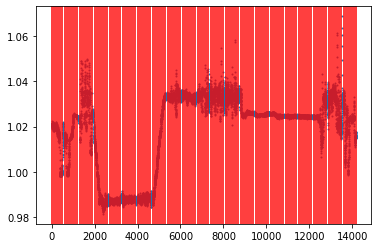

Pass number = 1
[[0, 200], [200, 400], [400, 600], [600, 800], [800, 1000], [1000, 1200], [1200, 1400], [1400, 1600], [1600, 1800], [1800, 2000], [2000, 2200], [2200, 2400], [2400, 2600], [2600, 2800], [2800, 3000], [3000, 3200], [3200, 3400], [3400, 3600], [3600, 3800], [3800, 4000], [4000, 4200], [4200, 4400], [4400, 4600], [4600, 4800], [4800, 5000], [5000, 5200], [5200, 5400], [5400, 5600], [5600, 5800], [5800, 6000], [6000, 6200], [6200, 6400], [6400, 6600], [6600, 6800], [6800, 7000], [7000, 7200], [7200, 7400], [7400, 7600], [7600, 7800], [7800, 8000], [8000, 8200], [8200, 8400], [8400, 8600], [8600, 8800], [8800, 9000], [9000, 9200], [9200, 9400], [9400, 9600], [9600, 9800], [9800, 10000], [10000, 10200], [10200, 10400], [10400, 10600], [10600, 10800], [10800, 11000], [11000, 11200], [11200, 11400], [11400, 11600], [11600, 11800], [11800, 12000], [12000, 12200], [12200, 12400], [12400, 12600], [12600, 12800], [12800, 13000], [13000, 13200], [13200, 13400], [13400, 13600], [1360

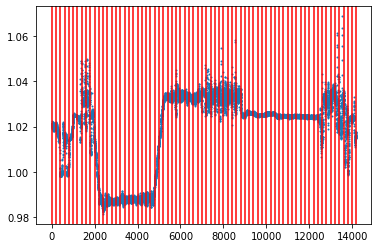

Pass number = 2
[[0, 400], [400, 800], [800, 1200], [1200, 1600], [1600, 2000], [2000, 2400], [2400, 2800], [2800, 3200], [3200, 3600], [3600, 4000], [4000, 4400], [4400, 4800], [4800, 5200], [5200, 5600], [5600, 6000], [6000, 6400], [6400, 6800], [6800, 7200], [7200, 7600], [7600, 8000], [8000, 8400], [8400, 8800], [8800, 9200], [9200, 9600], [9600, 10000], [10000, 10400], [10400, 10800], [10800, 11200], [11200, 11600], [11600, 12000], [12000, 12400], [12400, 12800], [12800, 13200], [13200, 13600], [13600, 14000], [14000, 14200]]


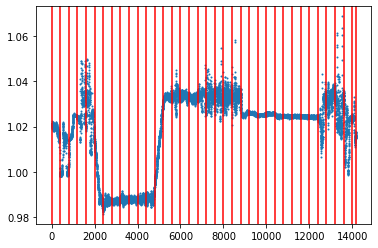

Pass number = 3
[[0, 400], [400, 1200], [1200, 2000], [2000, 2400], [2400, 2800], [2800, 3600], [3600, 4400], [4400, 4800], [4800, 5200], [5200, 5600], [5600, 6000], [6000, 6800], [6800, 7200], [7200, 8000], [8000, 8800], [8800, 9600], [9600, 10400], [10400, 11200], [11200, 11600], [11600, 12400], [12400, 13200], [13200, 13600], [13600, 14200]]


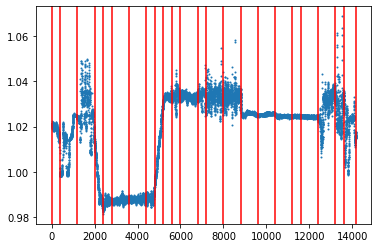

In [ ]:
seg_obj = Segmentation_Persistent_Homology('takens_embedding')
intervals_1 = seg_obj.get_segmentation(ts_arr, 100, threshold = 20, display_intermediate = True);
print(intervals_1)